# Walmart Store Sales — Exploratory Data Analysis

**Joint EDA** for the whole team. Runs on Kaggle and locally.

Competition metric: **WMAE** (holiday weeks weighted 5×).

Sections:
1. Load & merge data
2. Data overview & dtypes
3. Missing values
4. Target distribution (`Weekly_Sales`)
5. Sales over time & seasonality
6. Holiday effect
7. Store analysis (Type / Size)
8. Department analysis
9. External features & correlations
10. MarkDown analysis
11. Takeaways for modeling

In [1]:
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sophyrise/walmart-sales-forecasting.git"

if Path("/kaggle/input").exists():
    dst = Path("/kaggle/working/walmart-sales-forecasting")
    if not dst.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(dst)], check=True)
    sys.path.insert(0, str(dst))
else:
    sys.path.insert(0, str(Path.cwd().parent))

from src import config
print("On Kaggle:", config.ON_KAGGLE, "| raw data dir:", config.RAW_DIR)

On Kaggle: False | raw data dir: C:\Users\ThinkBook Yoga\PycharmProjects\walmart-sales-forecasting\data\raw


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data_loader as dl

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.max_columns', 40)

Matplotlib is building the font cache; this may take a moment.


## 1. Load & merge data

In [3]:
train = dl.load_merged('train')
test  = dl.load_merged('test')
print('train:', train.shape, '| test:', test.shape)
train.head()

train: (421570, 16) | test: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


## 2. Data overview & dtypes

In [4]:
print('Train date range:', train.Date.min().date(), '->', train.Date.max().date())
print('Test  date range:', test.Date.min().date(),  '->', test.Date.max().date())
print('Stores:', train.Store.nunique(), '| Departments:', train.Dept.nunique())
print('Store-Dept series:', train.groupby(["Store","Dept"]).ngroups)
train.info()

Train date range: 2010-02-05 -> 2012-10-26
Test  date range: 2012-11-02 -> 2013-07-26
Stores: 45 | Departments: 81
Store-Dept series: 3331


<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Type          421570 non-null  str           
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421570 non-nul

In [5]:
train.describe().T

,count,mean,min,25%,50%,75%,max,std
Store,421570.0,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,2011-06-18 08:30:31.963375,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
Size,421570.0,136727.915739,34875.0,93638.0,140167.0,202505.0,219622.0,60980.583328
Temperature,421570.0,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345
MarkDown2,111248.0,3334.628621,-265.76,41.6,192.0,1926.94,104519.54,9475.357325
MarkDown3,137091.0,1439.421384,-29.1,5.08,24.6,103.99,141630.61,9623.07829


## 3. Missing values
MarkDown1–5 are only recorded from Nov-2011 onward; CPI/Unemployment are missing for part of the test horizon.

In [6]:
miss = pd.DataFrame({'train': train.isna().mean(), 'test': test.reindex(columns=train.columns).isna().mean()})
miss = (miss[miss.sum(axis=1) > 0] * 100).round(1)
print('% missing per column'); miss

% missing per column


,train,test
Weekly_Sales,0.0,100.0
MarkDown1,64.3,0.1
MarkDown2,73.6,24.9
MarkDown3,67.5,8.5
MarkDown4,68.0,11.2
MarkDown5,64.1,0.0
CPI,0.0,33.2
Unemployment,0.0,33.2


## 4. Target distribution — `Weekly_Sales`

negatives: 1285 | zeros: 73
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


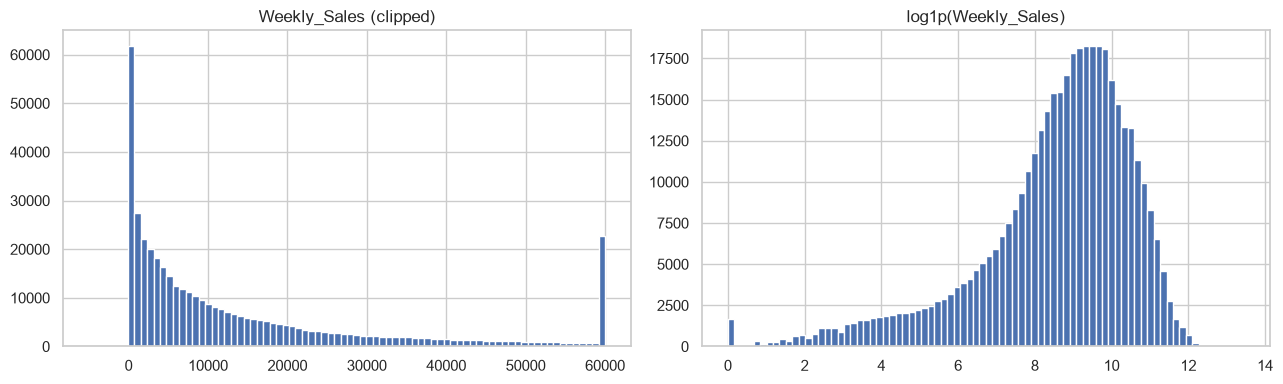

In [7]:
y = train['Weekly_Sales']
print('negatives:', int((y < 0).sum()), '| zeros:', int((y == 0).sum()))
print(y.describe())
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(y.clip(-5000, 60000), bins=80); ax[0].set_title('Weekly_Sales (clipped)')
ax[1].hist(np.log1p(y.clip(lower=0)), bins=80); ax[1].set_title('log1p(Weekly_Sales)')
plt.tight_layout(); plt.show()

## 5. Sales over time & seasonality

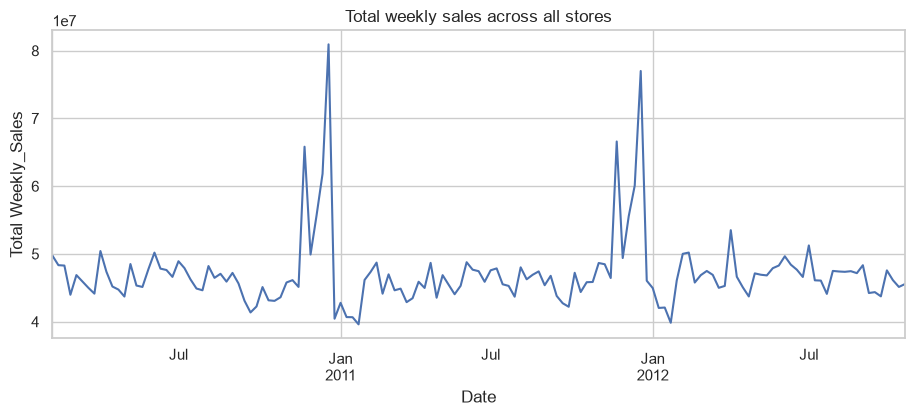

In [8]:
weekly = train.groupby('Date')['Weekly_Sales'].sum()
ax = weekly.plot(title='Total weekly sales across all stores')
ax.set_ylabel('Total Weekly_Sales'); plt.show()

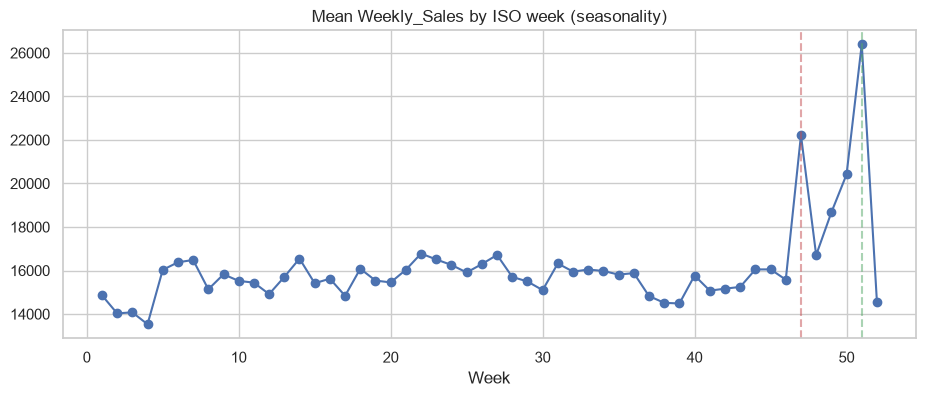

In [9]:
train['Week'] = train['Date'].dt.isocalendar().week.astype(int)
wk = train.groupby('Week')['Weekly_Sales'].mean()
wk.plot(marker='o', title='Mean Weekly_Sales by ISO week (seasonality)')
plt.axvline(47, color='r', ls='--', alpha=.5)
plt.axvline(51, color='g', ls='--', alpha=.5)
plt.show()

## 6. Holiday effect (weighted 5× in WMAE)

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661


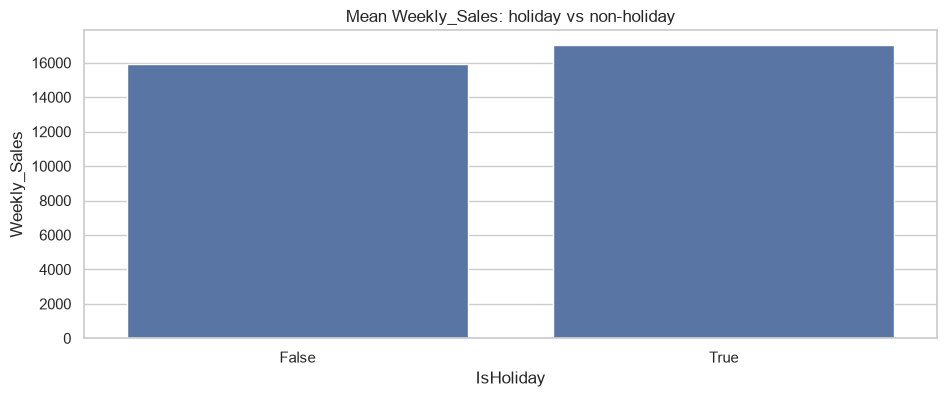

In [10]:
h = train.groupby('IsHoliday')['Weekly_Sales'].agg(['mean','median','count'])
print(h)
sns.barplot(data=train, x='IsHoliday', y='Weekly_Sales', estimator=np.mean, errorbar=None)
plt.title('Mean Weekly_Sales: holiday vs non-holiday'); plt.show()

## 7. Store analysis — Type & Size

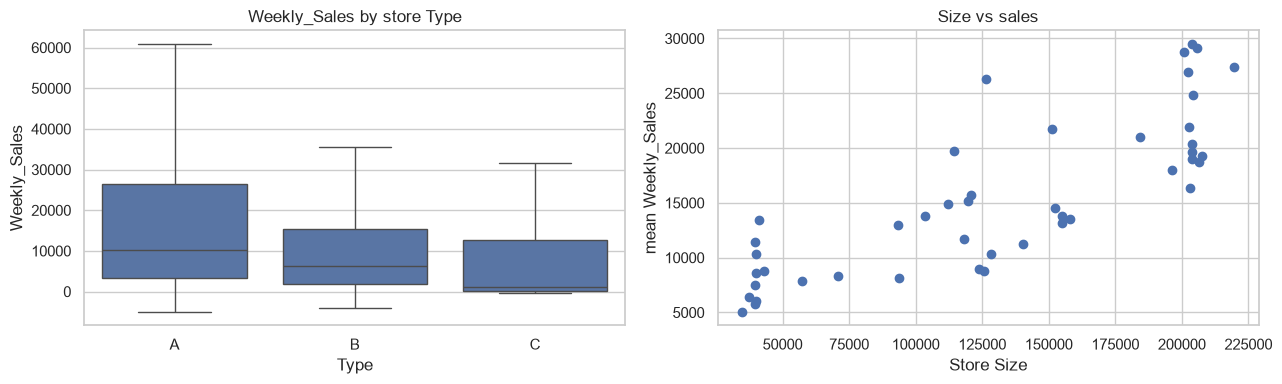

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=train, x='Type', y='Weekly_Sales', order=['A','B','C'], ax=ax[0], showfliers=False)
ax[0].set_title('Weekly_Sales by store Type')
store_size = train.groupby('Store').agg(Size=('Size','first'), sales=('Weekly_Sales','mean'))
ax[1].scatter(store_size['Size'], store_size['sales'])
ax[1].set_xlabel('Store Size'); ax[1].set_ylabel('mean Weekly_Sales'); ax[1].set_title('Size vs sales')
plt.tight_layout(); plt.show()

## 8. Department analysis

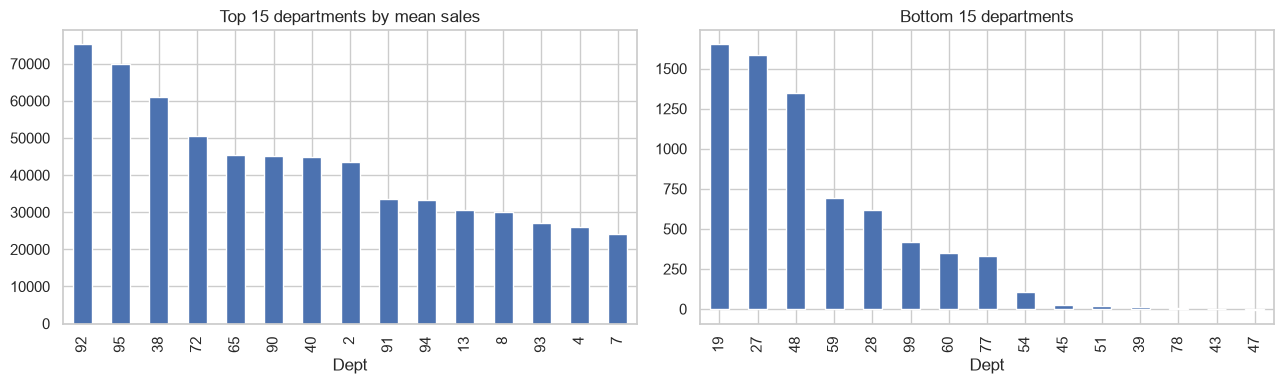

In [12]:
dept = train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dept.head(15).plot.bar(ax=ax[0], title='Top 15 departments by mean sales')
dept.tail(15).plot.bar(ax=ax[1], title='Bottom 15 departments')
plt.tight_layout(); plt.show()

## 9. External features & correlations

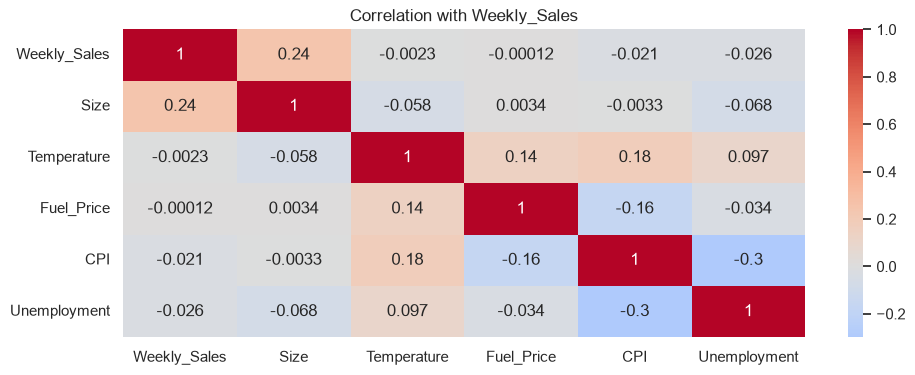

In [13]:
num = ['Weekly_Sales','Size','Temperature','Fuel_Price','CPI','Unemployment']
corr = train[num].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Weekly_Sales'); plt.show()

## 10. MarkDown analysis

any_markdown
False    15871.522017
True     16177.015244
Name: Weekly_Sales, dtype: float64


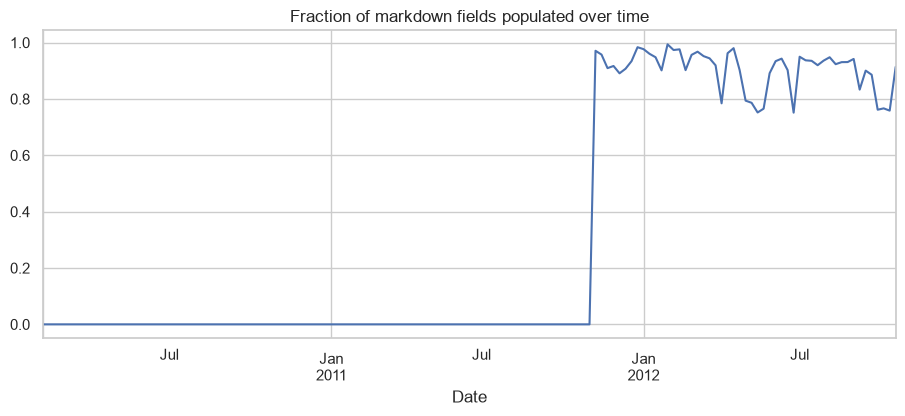

In [14]:
md_cols = [f'MarkDown{i}' for i in range(1,6)]
md = train.copy()
md[md_cols] = md[md_cols].apply(pd.to_numeric, errors='coerce')
md['any_markdown'] = md[md_cols].notna().any(axis=1)
print(md.groupby('any_markdown')['Weekly_Sales'].mean())
md.groupby('Date')[md_cols].apply(lambda d: d.notna().mean().mean()).plot(
    title='Fraction of markdown fields populated over time'); plt.show()

## 11. Takeaways for modeling

- **Strong weekly seasonality** with Thanksgiving (wk 47) and Christmas (wk 51) spikes → calendar & cyclical features matter.
- **Store `Type`/`Size` and `Dept`** are the dominant drivers → keep as categorical/ordinal features.
- **MarkDowns are missing pre-Nov-2011** → impute as 0 ("no markdown") rather than mean.
- **~1.3k negative sales** (returns) → clip predictions at 0 for submission.
- **Holiday weeks weighted 5×** → validate with WMAE, consider sample weights when training.
- Per `(Store, Dept)` series are short (~143 weeks) → global tree models likely beat per-series ARIMA.